# Single-Sensor Deployment Example

This notebook loads the stored configuration-conditional calibration artifact and applies it to one sensor stream. Unlike the old same-scene calibration flow, deployment only needs:

- the stored model,
- the deployed sensor identifier,
- the deployed campaign configuration,
- the deployed frequency grid,
- and that sensor's raw observations.

No shared-scene assumption is required at deployment time.

In [1]:
# Shared workflow configuration lives under ``config/notebook_workflow/``.
# Edit those files instead of maintaining notebook-local campaign or node lists.
NOTEBOOK_WORKFLOW_CONFIG_DIRNAME = "config/notebook_workflow"

# Optional notebook-local deployment overrides within the configured testing split.
DEPLOYMENT_CAMPAIGN_LABEL = None
DEPLOYMENT_SENSOR_ID = "Node3"

In [2]:
from __future__ import annotations

from pathlib import Path
import shutil
import sys
from tempfile import mkdtemp

from IPython.display import HTML, display
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def resolve_repo_root() -> Path:
    """Return the repository root regardless of the current notebook cwd."""

    for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
        if (candidate / "measurement_calibration").exists() and (candidate / "notebooks").exists():
            return candidate
    raise RuntimeError("Could not resolve the repository root from the notebook cwd")


REPO_ROOT = resolve_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from measurement_calibration import (
    DEFAULT_ARCHIVED_ARTIFACTS_DIR,
    DEFAULT_CAMPAIGNS_DATA_DIR,
    DEFAULT_PRODUCTION_ARTIFACT_DIR,
    DEFAULT_PRODUCTION_PARAMETERS_FILENAME,
    FileSystemCampaignSensorDataRepository,
    FrequencyBasisConfig,
    PersistentModelConfig,
    TwoLevelFitConfig,
    archive_artifact_directory,
    calibrate_sensor_observations,
    evaluate_persistent_calibration,
    fit_and_save_calibration_corpus_model,
    load_notebook_workflow_config,
    load_two_level_calibration_artifact,
    power_linear_to_db,
    prepare_calibration_campaign,
    prepare_calibration_corpus,
    resolve_global_excluded_sensor_ids_by_campaign,
)

CAMPAIGNS_ROOT = REPO_ROOT / DEFAULT_CAMPAIGNS_DATA_DIR
PRODUCTION_MODEL_DIR = REPO_ROOT / DEFAULT_PRODUCTION_ARTIFACT_DIR
ARCHIVE_MODELS_ROOT = REPO_ROOT / DEFAULT_ARCHIVED_ARTIFACTS_DIR
PRODUCTION_MODEL_DIR.parent.mkdir(parents=True, exist_ok=True)
WORKFLOW_CONFIG = load_notebook_workflow_config(
    REPO_ROOT / NOTEBOOK_WORKFLOW_CONFIG_DIRNAME
)
TRAINING_CAMPAIGN_LABELS = WORKFLOW_CONFIG.training_campaign_labels
TESTING_CAMPAIGN_LABELS = WORKFLOW_CONFIG.testing_campaign_labels
WORKFLOW_CAMPAIGN_LABELS = WORKFLOW_CONFIG.workflow_campaign_labels
EXCLUDED_NODES = WORKFLOW_CONFIG.excluded_sensor_ids

CAMPAIGN_REPOSITORY = FileSystemCampaignSensorDataRepository(
    campaigns_root=CAMPAIGNS_ROOT
)
AVAILABLE_CAMPAIGN_LABELS = CAMPAIGN_REPOSITORY.list_campaign_labels()
missing_campaign_labels = sorted(
    set(WORKFLOW_CAMPAIGN_LABELS).difference(AVAILABLE_CAMPAIGN_LABELS)
)
if missing_campaign_labels:
    raise ValueError(
        "Notebook workflow configuration references campaigns that do not exist "
        f"under {CAMPAIGNS_ROOT}: {missing_campaign_labels}"
    )

GLOBAL_EXCLUDED_SENSOR_IDS_BY_CAMPAIGN = resolve_global_excluded_sensor_ids_by_campaign(
    campaign_labels=WORKFLOW_CAMPAIGN_LABELS,
    excluded_sensor_ids=EXCLUDED_NODES,
    campaigns_root=CAMPAIGNS_ROOT,
)
TRAINING_EXCLUDED_SENSOR_IDS_BY_CAMPAIGN = {
    campaign_label: GLOBAL_EXCLUDED_SENSOR_IDS_BY_CAMPAIGN[campaign_label]
    for campaign_label in TRAINING_CAMPAIGN_LABELS
}
TESTING_EXCLUDED_SENSOR_IDS_BY_CAMPAIGN = {
    campaign_label: GLOBAL_EXCLUDED_SENSOR_IDS_BY_CAMPAIGN[campaign_label]
    for campaign_label in TESTING_CAMPAIGN_LABELS
}
if DEPLOYMENT_CAMPAIGN_LABEL is None:
    DEPLOYMENT_CAMPAIGN_LABEL = TESTING_CAMPAIGN_LABELS[0]
elif DEPLOYMENT_CAMPAIGN_LABEL not in TESTING_CAMPAIGN_LABELS:
    raise ValueError(
        "DEPLOYMENT_CAMPAIGN_LABEL must belong to the configured testing split, "
        f"got {DEPLOYMENT_CAMPAIGN_LABEL!r} not in {TESTING_CAMPAIGN_LABELS}"
    )

BASIS_CONFIG = FrequencyBasisConfig(
    n_gain_basis=10,
    n_floor_basis=8,
    n_variance_basis=8,
    spline_degree=3,
)
MODEL_CONFIG = PersistentModelConfig(
    sensor_embedding_dim=4,
    configuration_latent_dim=4,
)
FIT_CONFIG = TwoLevelFitConfig(
    n_outer_iterations=8,
    n_gradient_steps=20,
    learning_rate=0.03,
    sigma_min=1.0e-8,
    adaptive_variance_floor_ratio=1.0e-4,
    select_best_outer_iterate=True,
    early_stopping_patience=5,
    divergence_tolerance_ratio=10.0,
    refresh_campaign_variance_from_residuals=True,
    variance_refresh_ridge=1.0e-6,
)

pd.set_option("display.max_columns", 32)
pd.set_option("display.max_rows", 32)

## Load Or Build The Stored Model

The deployment notebook is self-contained: if `models/production/` does not contain a manifest yet, it fits the same lightweight training configuration, writes `model.npz`, archives any previous production bundle, and then loads the promoted production artifact.

In [3]:
if not (PRODUCTION_MODEL_DIR / "manifest.json").exists():
    staging_output_dir = Path(
        mkdtemp(prefix=".production_staging__", dir=PRODUCTION_MODEL_DIR.parent)
    )
    try:
        preparation = prepare_calibration_corpus(
            campaign_labels=TRAINING_CAMPAIGN_LABELS,
            campaigns_root=CAMPAIGNS_ROOT,
            excluded_sensor_ids_by_campaign=TRAINING_EXCLUDED_SENSOR_IDS_BY_CAMPAIGN,
        )
        fit_and_save_calibration_corpus_model(
            preparation=preparation,
            output_dir=staging_output_dir,
            basis_config=BASIS_CONFIG,
            model_config=MODEL_CONFIG,
            fit_config=FIT_CONFIG,
            parameters_filename=DEFAULT_PRODUCTION_PARAMETERS_FILENAME,
        )
        archive_artifact_directory(
            output_dir=PRODUCTION_MODEL_DIR,
            archive_root=ARCHIVE_MODELS_ROOT,
            archive_label="production",
        )
        if PRODUCTION_MODEL_DIR.exists():
            PRODUCTION_MODEL_DIR.rmdir()
        staging_output_dir.rename(PRODUCTION_MODEL_DIR)
    except Exception:
        shutil.rmtree(staging_output_dir, ignore_errors=True)
        raise

artifact = load_two_level_calibration_artifact(PRODUCTION_MODEL_DIR)
deployment_excluded_sensor_ids = TESTING_EXCLUDED_SENSOR_IDS_BY_CAMPAIGN[
    DEPLOYMENT_CAMPAIGN_LABEL
]
deployment_campaign = prepare_calibration_campaign(
    campaign_label=DEPLOYMENT_CAMPAIGN_LABEL,
    campaigns_root=CAMPAIGNS_ROOT,
    excluded_sensor_ids=deployment_excluded_sensor_ids,
)
available_sensor_ids = deployment_campaign.campaign.sensor_ids
sensor_id = (
    DEPLOYMENT_SENSOR_ID
    if DEPLOYMENT_SENSOR_ID in available_sensor_ids
    else deployment_campaign.reliable_sensor_id
)
sensor_index = available_sensor_ids.index(sensor_id)

deployment_inputs = pd.DataFrame(
    [
        {
            "model_dir": str(PRODUCTION_MODEL_DIR.relative_to(REPO_ROOT)),
            "model_file": artifact.parameters_path.name,
            "training_campaigns": ", ".join(TRAINING_CAMPAIGN_LABELS),
            "testing_campaigns": ", ".join(TESTING_CAMPAIGN_LABELS),
            "excluded_nodes": ", ".join(EXCLUDED_NODES) or "-",
            "deployment_campaign": deployment_campaign.campaign_label,
            "deployment_sensor_id": sensor_id,
            "reliable_sensor_id": deployment_campaign.reliable_sensor_id,
            "excluded_sensor_ids": ", ".join(deployment_excluded_sensor_ids) or "-",
            "n_records": deployment_campaign.campaign.n_acquisitions,
            "n_frequencies": deployment_campaign.campaign.n_frequencies,
            "central_freq_MHz": deployment_campaign.campaign.configuration.central_frequency_hz / 1.0e6,
            "span_MHz": deployment_campaign.campaign.configuration.span_hz / 1.0e6,
            "rbw_kHz": deployment_campaign.campaign.configuration.resolution_bandwidth_hz / 1.0e3,
        }
    ]
)
display(deployment_inputs)

,model_dir,model_file,training_campaigns,testing_campaigns,excluded_nodes,deployment_campaign,deployment_sensor_id,reliable_sensor_id,excluded_sensor_ids,n_records,n_frequencies,central_freq_MHz,span_MHz,rbw_kHz
0,models/production,model.npz,"LNA16_VGA0, LNA16_VGA16, LNA16_VGA32, LNA16_VG...",test-calibration,"Node9, Node10",test-calibration,Node3,Node2,Node10,4,4096,98.0,20.0,10.0


## Evaluate Persistent Laws And Calibrate One Sensor Stream

The next cell uses only the selected sensor's observations. The trust diagnostics expose whether the request lies inside the training support in frequency and configuration space.

In [4]:
raw_power = deployment_campaign.campaign.observations_power[sensor_index]
curves = evaluate_persistent_calibration(
    result=artifact.result,
    sensor_id=sensor_id,
    configuration=deployment_campaign.campaign.configuration,
    frequency_hz=deployment_campaign.campaign.frequency_hz,
)
deployment = calibrate_sensor_observations(
    result=artifact.result,
    sensor_id=sensor_id,
    configuration=deployment_campaign.campaign.configuration,
    frequency_hz=deployment_campaign.campaign.frequency_hz,
    observations_power=raw_power,
)

trust_frame = pd.DataFrame(
    [
        {
            "frequency_support_hz": curves.trust_diagnostics.frequency_support_hz,
            "requested_frequency_hz": curves.trust_diagnostics.requested_frequency_hz,
            "frequency_extrapolation_detected": curves.trust_diagnostics.frequency_extrapolation_detected,
            "configuration_out_of_distribution": curves.trust_diagnostics.configuration_out_of_distribution,
            "out_of_range_feature_names": ", ".join(curves.trust_diagnostics.out_of_range_feature_names) or "-",
            "max_abs_standardized_feature": curves.trust_diagnostics.max_abs_standardized_feature,
        }
    ]
)
display(trust_frame)

summary_frame = pd.DataFrame(
    [
        {
            "mean_raw_power_db": float(power_linear_to_db(raw_power).mean()),
            "mean_corrected_power_db": float(power_linear_to_db(deployment.calibrated_power).mean()),
            "mean_gain_db": float(power_linear_to_db(curves.gain_power).mean()),
            "mean_floor_db": float(power_linear_to_db(curves.additive_noise_power).mean()),
            "mean_propagated_variance_db": float(power_linear_to_db(deployment.propagated_variance_power2).mean()),
        }
    ]
)
display(summary_frame)

,frequency_support_hz,requested_frequency_hz,frequency_extrapolation_detected,configuration_out_of_distribution,out_of_range_feature_names,max_abs_standardized_feature
0,"(88000000.0, 108000000.0)","(88000000.0, 108000000.0)",False,False,-,2.0


,mean_raw_power_db,mean_corrected_power_db,mean_gain_db,mean_floor_db,mean_propagated_variance_db
0,-20.258793,-20.351709,0.092903,-77.081495,9.607299


## Deployment Plots

The first row compares one deployed PSD realization before and after calibration. The second row shows the mean deployed spectrum and the persistent calibration laws used for this sensor/configuration pair.

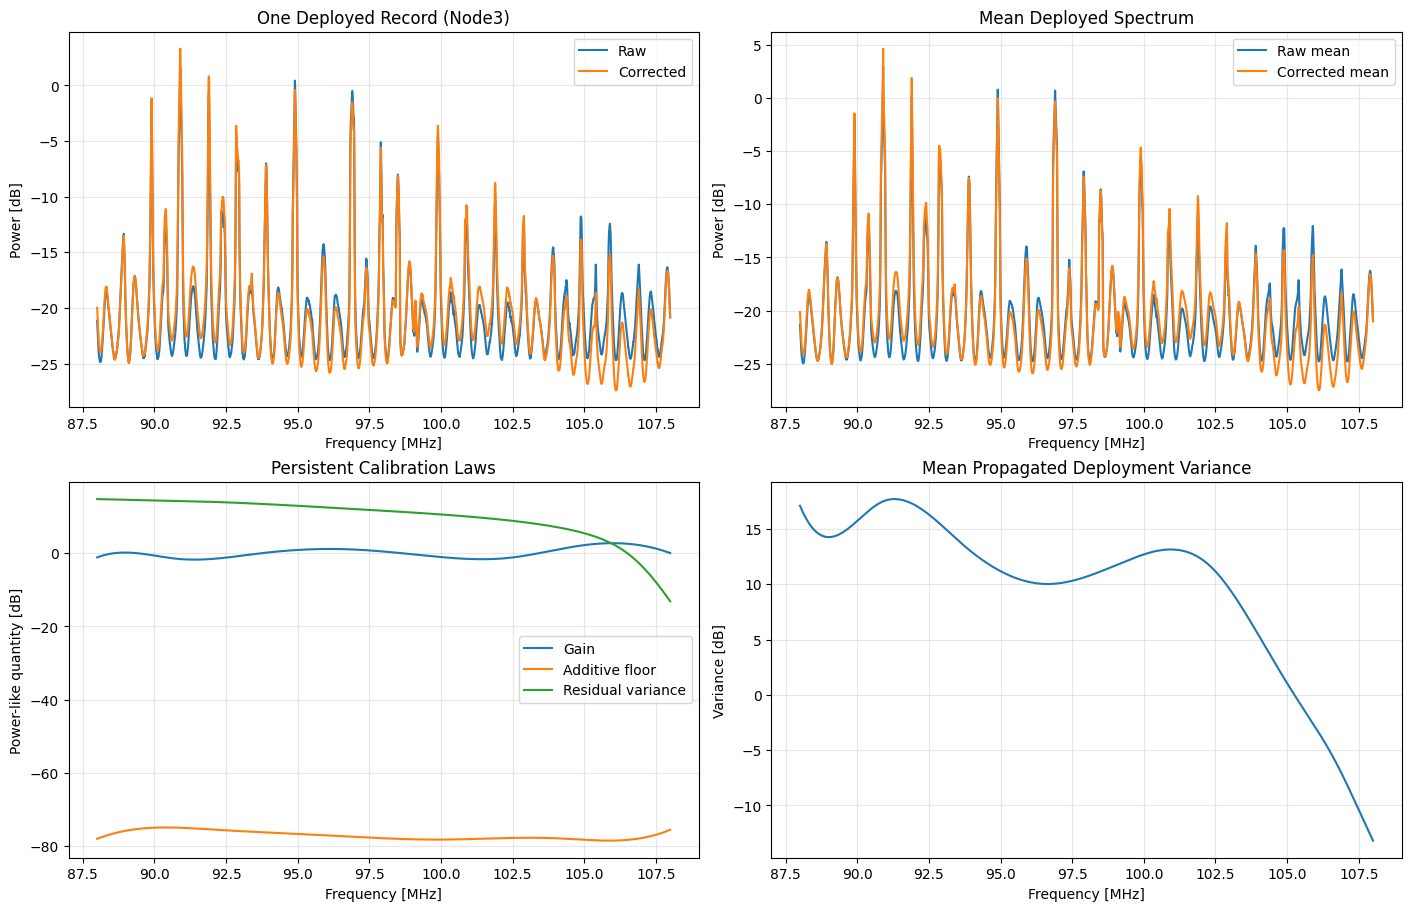

In [5]:
record_index = 0
frequency_mhz = deployment_campaign.campaign.frequency_hz / 1.0e6
raw_record_db = power_linear_to_db(raw_power[record_index])
corrected_record_db = power_linear_to_db(deployment.calibrated_power[record_index])
raw_mean_db = power_linear_to_db(np.mean(raw_power, axis=0))
corrected_mean_db = power_linear_to_db(np.mean(deployment.calibrated_power, axis=0))

fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)

axes[0, 0].plot(frequency_mhz, raw_record_db, label="Raw")
axes[0, 0].plot(frequency_mhz, corrected_record_db, label="Corrected")
axes[0, 0].set_title(f"One Deployed Record ({sensor_id})")
axes[0, 0].set_xlabel("Frequency [MHz]")
axes[0, 0].set_ylabel("Power [dB]")
axes[0, 0].grid(alpha=0.3)
axes[0, 0].legend(loc="best")

axes[0, 1].plot(frequency_mhz, raw_mean_db, label="Raw mean")
axes[0, 1].plot(frequency_mhz, corrected_mean_db, label="Corrected mean")
axes[0, 1].set_title("Mean Deployed Spectrum")
axes[0, 1].set_xlabel("Frequency [MHz]")
axes[0, 1].set_ylabel("Power [dB]")
axes[0, 1].grid(alpha=0.3)
axes[0, 1].legend(loc="best")

axes[1, 0].plot(frequency_mhz, power_linear_to_db(curves.gain_power), label="Gain")
axes[1, 0].plot(
    frequency_mhz,
    power_linear_to_db(curves.additive_noise_power),
    label="Additive floor",
)
axes[1, 0].plot(
    frequency_mhz,
    power_linear_to_db(curves.residual_variance_power2),
    label="Residual variance",
)
axes[1, 0].set_title("Persistent Calibration Laws")
axes[1, 0].set_xlabel("Frequency [MHz]")
axes[1, 0].set_ylabel("Power-like quantity [dB]")
axes[1, 0].grid(alpha=0.3)
axes[1, 0].legend(loc="best")

axes[1, 1].plot(
    frequency_mhz,
    power_linear_to_db(np.mean(deployment.propagated_variance_power2, axis=0)),
)
axes[1, 1].set_title("Mean Propagated Deployment Variance")
axes[1, 1].set_xlabel("Frequency [MHz]")
axes[1, 1].set_ylabel("Variance [dB]")
axes[1, 1].grid(alpha=0.3)

plt.show()

## Full-Campaign Reconstruction Animation

This final diagnostic calibrates every valid sensor in the selected deployment campaign and reconstructs each observed PSD with the stored persistent laws:

- `calibrated_power = [Y - N]_+ / G`
- `reconstructed_power = G * calibrated_power + N`

The animation renders every aligned PSD record across all valid nodes. For notebook responsiveness, only the displayed frequency axis is downsampled; the calibration itself still runs on the full grid.

In [6]:
ANIMATION_FREQUENCY_TARGET = 128
animation_stride = max(1, deployment_campaign.campaign.n_frequencies // ANIMATION_FREQUENCY_TARGET)
animation_frequency_mhz = deployment_campaign.campaign.frequency_hz[::animation_stride] / 1.0e6

reconstruction_by_sensor = {}
reconstruction_rows = []
for current_sensor_id in deployment_campaign.campaign.sensor_ids:
    current_sensor_index = deployment_campaign.campaign.sensor_ids.index(current_sensor_id)
    current_raw_power = deployment_campaign.campaign.observations_power[current_sensor_index]
    current_curves = evaluate_persistent_calibration(
        result=artifact.result,
        sensor_id=current_sensor_id,
        configuration=deployment_campaign.campaign.configuration,
        frequency_hz=deployment_campaign.campaign.frequency_hz,
    )
    current_deployment = calibrate_sensor_observations(
        result=artifact.result,
        sensor_id=current_sensor_id,
        configuration=deployment_campaign.campaign.configuration,
        frequency_hz=deployment_campaign.campaign.frequency_hz,
        observations_power=current_raw_power,
    )
    current_reconstructed_power = (
        current_curves.gain_power[np.newaxis, :] * current_deployment.calibrated_power
        + current_curves.additive_noise_power[np.newaxis, :]
    )
    reconstruction_by_sensor[current_sensor_id] = {
        'raw_db': power_linear_to_db(current_raw_power[:, ::animation_stride]),
        'reconstructed_db': power_linear_to_db(current_reconstructed_power[:, ::animation_stride]),
    }
    reconstruction_rows.append(
        {
            'sensor_id': current_sensor_id,
            'n_records': current_raw_power.shape[0],
            'mean_reconstruction_rmse_db': float(
                np.sqrt(
                    np.mean(
                        (
                            power_linear_to_db(current_raw_power)
                            - power_linear_to_db(current_reconstructed_power)
                        ) ** 2
                    )
                )
            ),
        }
    )

display(pd.DataFrame(reconstruction_rows).sort_values('sensor_id'))

valid_sensor_ids = tuple(reconstruction_by_sensor)
n_sensors = len(valid_sensor_ids)
n_cols = 2
n_rows = int(np.ceil(n_sensors / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.8 * n_rows), constrained_layout=True)
axes = np.atleast_1d(axes).ravel()

all_animation_values_db = np.concatenate(
    [
        np.concatenate(
            [
                reconstruction_by_sensor[sensor_id]['raw_db'].reshape(-1),
                reconstruction_by_sensor[sensor_id]['reconstructed_db'].reshape(-1),
            ]
        )
        for sensor_id in valid_sensor_ids
    ]
)
y_min_db = float(np.min(all_animation_values_db)) - 1.0
y_max_db = float(np.max(all_animation_values_db)) + 1.0

line_handles = {}
for axis, sensor_id in zip(axes, valid_sensor_ids, strict=False):
    raw_line, = axis.plot([], [], label='Raw', linewidth=1.1)
    reconstructed_line, = axis.plot([], [], label='Reconstructed', linewidth=1.1)
    axis.set_xlim(animation_frequency_mhz[0], animation_frequency_mhz[-1])
    axis.set_ylim(y_min_db, y_max_db)
    axis.set_xlabel('Frequency [MHz]')
    axis.set_ylabel('Power [dB]')
    axis.grid(alpha=0.3)
    axis.legend(loc='best')
    line_handles[sensor_id] = (raw_line, reconstructed_line, axis)

for axis in axes[n_sensors:]:
    axis.set_visible(False)


def update_animation(record_index: int):
    for sensor_id, (raw_line, reconstructed_line, axis) in line_handles.items():
        raw_line.set_data(
            animation_frequency_mhz,
            reconstruction_by_sensor[sensor_id]['raw_db'][record_index],
        )
        reconstructed_line.set_data(
            animation_frequency_mhz,
            reconstruction_by_sensor[sensor_id]['reconstructed_db'][record_index],
        )
        axis.set_title(
            f"{sensor_id} | record {record_index + 1}/{deployment_campaign.campaign.n_acquisitions}"
        )
    fig.suptitle(
        f"PSD Reconstruction Across Valid Nodes | {deployment_campaign.campaign_label}",
        fontsize=14,
    )
    artists = []
    for raw_line, reconstructed_line, _ in line_handles.values():
        artists.extend((raw_line, reconstructed_line))
    return artists

animation = FuncAnimation(
    fig,
    update_animation,
    frames=deployment_campaign.campaign.n_acquisitions,
    interval=250,
    blit=False,
    cache_frame_data=False,
)
plt.close(fig)
HTML(animation.to_jshtml(default_mode='once'))

,sensor_id,n_records,mean_reconstruction_rmse_db
0,Node1,4,7.576799e-17
1,Node2,4,8.796562e-17
2,Node3,4,8.889380e-17
